# **1. Project Overview**

The objective of this project is to analyze adverse drug event reports from the FDA Adverse Event Reporting System (FAERS) and identify patterns related to patient demographics, reported reactions, clinical outcomes, and drug safety risks.

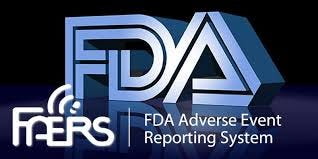


Using Python-based exploratory data analysis, the project investigates:

Demographic characteristics of adverse event reports
Most frequently reported adverse reactions
Reactions associated with severe outcomes such as death and hospitalization
Drug safety patterns and high-risk medications
Common drug–reaction associations

The analysis is organized into three modules:

***Module 1 — Demographic Analysis***

Examines age distribution, gender trends, country-level reporting patterns, and severe outcome rates across patient groups.

***Module 2 — Reaction Analysis***

Investigates the most frequently reported adverse reactions, reactions associated with death and hospitalization, and reaction patterns across demographic segments.

***Module 3 — Drug Risk Analysis***

Analyzes frequently reported drugs, drugs linked to severe outcomes, drug role classifications, and common drug–reaction pairs.

# **2. Dataset Overview**

The FDA Adverse Event Reporting System (FAERS) is a pharmacovigilance database maintained by the U.S. Food and Drug Administration (FDA). It contains voluntarily submitted reports of adverse drug events, medication errors, and product quality complaints reported by healthcare professionals, consumers, and manufacturers.

This analysis uses four core FAERS tables to investigate demographic patterns, adverse reactions, patient outcomes, and drug safety signals.

**Original Descriptions**
1. DEMOyyQq.TXT contains patient demographic and administrative
information, a single record for each event report.
2. DRUGyyQq.TXT contains drug/biologic information for as many
medications as were reported for the event (1 or more per event).
5
3. REACyyQq.TXT contains all "Medical Dictionary for Regulatory
Activities" (MedDRA) terms coded for the event (1 or more). For more
information on MedDRA, please contact: TRW, VAR 1/6A/MSSO, 12011 Sunset
Hills Road, Reston, VA 20190-3285, USA; website is www.meddramsso.com
4. OUTCyyQq.TXT contains patient outcomes for the event (0 or more).
5. RPSRyyQq.TXT contains report sources for event (0 or more).
6. THERyyQq.TXT contains drug therapy start dates and end dates for the
reported drugs (0 or more per drug per event).
7. INDIyyQq.TXT contains all "Medical Dictionary for Regulatory
Activities" (MedDRA) terms coded for the indications for use
(diagnoses) for the reported drugs (0 or more per drug per event).

# **3. Data Loading**

In [1]:
import pandas as pd
demo = pd.read_csv("DEMO26Q1.txt", sep = "$", encoding = "latin", on_bad_lines="skip")

demo.head()

/tmp/ipykernel_2174/128665421.py:2: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  demo = pd.read_csv("DEMO26Q1.txt", sep = "$", encoding = "latin", on_bad_lines="skip")


,primaryid,caseid,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,age_grp,sex,e_sub,wt,wt_cod,rept_dt,to_mfr,occp_cod,reporter_country,occr_country
0,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,NaN,F,Y,NaN,NaN,20260203.0,NaN,HP,CA,CA
1,100293665,10029366.0,5.0,F,NaN,20251229.0,20140322.0,20260106.0,EXP,NaN,...,NaN,M,Y,NaN,NaN,20260106.0,NaN,HP,AU,AU
2,1005450711,10054507.0,11.0,F,NaN,20260114.0,20140402.0,20260120.0,PER,NaN,...,E,F,Y,NaN,NaN,20260120.0,NaN,MD,US,US
3,1005762126,10057621.0,26.0,F,20140204.0,20260112.0,20140404.0,20260127.0,EXP,NaN,...,A,M,Y,53.0,KG,20260127.0,NaN,MD,CA,CA
4,100670805,10067080.0,5.0,F,NaN,20140428.0,20260119.0,20260119.0,PER,NaN,...,NaN,M,Y,NaN,NaN,20260119.0,NaN,MD,TR,US


In [2]:
demo.columns

Index(['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt',
       'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num', 'mfr_num', 'mfr_sndr',
       'lit_ref', 'age', 'age_cod', 'age_grp', 'sex', 'e_sub', 'wt', 'wt_cod',
       'rept_dt', 'to_mfr', 'occp_cod', 'reporter_country', 'occr_country'],
      dtype='object')

In [3]:
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230274 entries, 0 to 230273
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   primaryid         230274 non-null  int64  
 1   caseid            230273 non-null  float64
 2   caseversion       230273 non-null  float64
 3   i_f_code          230273 non-null  object 
 4   event_dt          105760 non-null  float64
 5   mfr_dt            230273 non-null  float64
 6   init_fda_dt       230273 non-null  float64
 7   fda_dt            230273 non-null  float64
 8   rept_cod          230273 non-null  object 
 9   auth_num          16922 non-null   object 
 10  mfr_num           225654 non-null  object 
 11  mfr_sndr          230273 non-null  object 
 12  lit_ref           15195 non-null   object 
 13  age               147857 non-null  float64
 14  age_cod           147861 non-null  object 
 15  age_grp           78718 non-null   object 
 16  sex               19

In [4]:
demo.shape

(230274, 25)

# **4. Data Quality Assessment**


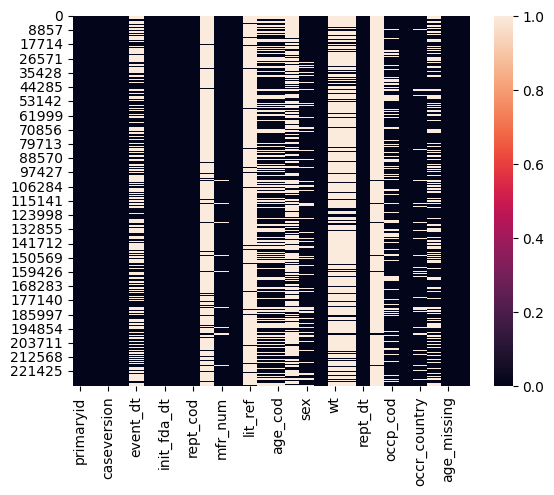

In [129]:
# Checking Missing Values

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(demo.isnull())
plt.show()

In [130]:
# Checking percentage of missing values with respect to columns

missing_percent = (demo.isnull().sum() / len(demo)) * 100

missing_percent = missing_percent.sort_values(ascending=False)

missing_percent

,0
to_mfr,98.173915
lit_ref,93.401339
auth_num,92.651363
wt,81.347438
wt_cod,81.347438
age_grp,65.815507
event_dt,54.072105
age,35.790840
age_years,35.790840
age_cod,35.789103


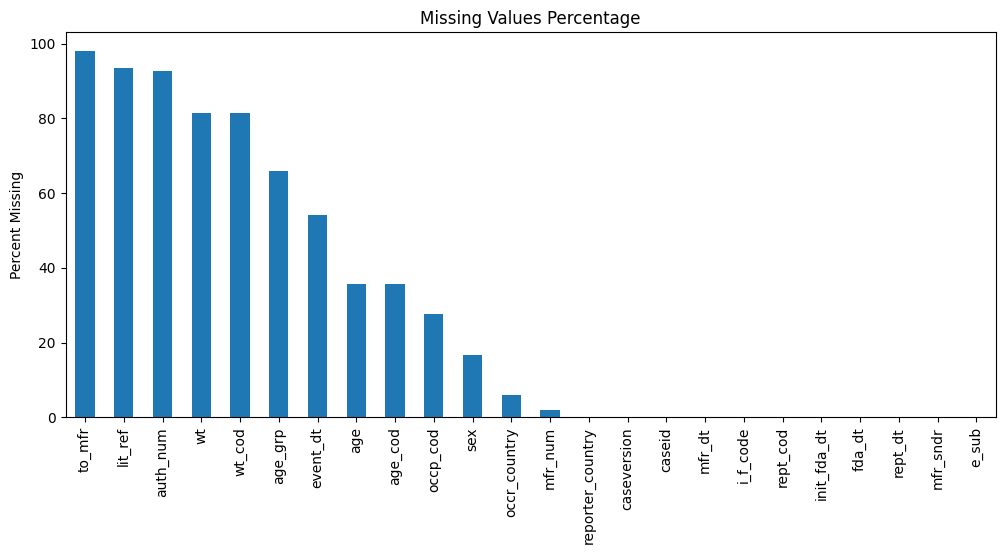

In [7]:
missing_percent[missing_percent > 0].plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Missing Values Percentage")
plt.ylabel("Percent Missing")
plt.show()

In [8]:
demo["age"].describe()

,age
count,147857.000000
mean,53.895764
std,23.770424
min,0.000000
25%,39.000000
50%,58.000000
75%,70.000000
max,936.000000


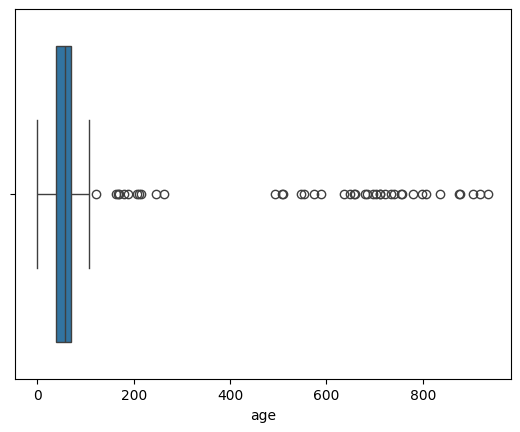

In [9]:
# Checking For Outliers In Age Years With Boxplot

sns.boxplot(x=demo["age"])
plt.show()

In [10]:
demo["sex"].value_counts(dropna=False)

demo["reporter_country"].value_counts().head(20)

,count
reporter_country,
US,157516
EU,22577
CA,12964
JP,9762
GB,7658
CN,4381
COUNTRY NOT SPECIFIED,2008
AU,1534
IN,1493


In [11]:
demo["age_cod"].value_counts(dropna=False)

,count
age_cod,
YR,144609
NaN,82413
DEC,2363
MON,659
DY,152
WK,70
HR,8


# **5. Data Preparation & Feature Engineering**

Age values in the FAERS dataset are reported using different units (years, months, weeks, days, hours, and decades).

To make age-based analysis consistent, all age values are converted into a common unit of years and stored in a new column called 'age_years'.

This allows
accurate comparisons, grouping, and visualization across patients of different ages.

In [12]:


demo.loc[demo["age_cod"] == "YR", "age_years"] = demo["age"]

demo.loc[demo["age_cod"] == "DEC", "age_years"] = (
    demo["age"] * 10
)

demo.loc[demo["age_cod"] == "MON", "age_years"] = (
    demo["age"] / 12
)

demo.loc[demo["age_cod"] == "WK", "age_years"] = (
    demo["age"] / 52
)

demo.loc[demo["age_cod"] == "DY", "age_years"] = (
    demo["age"] / 365
)

demo.loc[demo["age_cod"] == "HR", "age_years"] = (
    demo["age"] / 8760
)





In [13]:
demo[["age", "age_cod", "age_years"]].head(20)

,age,age_cod,age_years
0,56.0,YR,56.0
1,32.0,YR,32.0
2,68.0,YR,68.0
3,57.0,YR,57.0
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,65.0,YR,65.0
7,58.0,YR,58.0
8,63.0,YR,63.0
9,65.0,YR,65.0


In [132]:
demo = demo[demo['age_years'] <= 120]

In [14]:
demo["age_cod"].value_counts(dropna=False)

,count
age_cod,
YR,144609
NaN,82413
DEC,2363
MON,659
DY,152
WK,70
HR,8


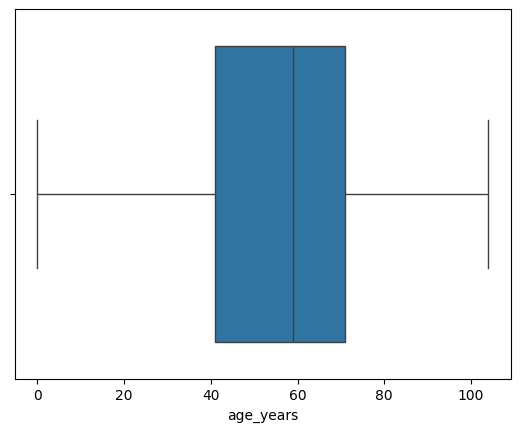

In [133]:
# Now we can see the cleaned and consistent box plot as compared to before for the 'age' column.

import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=demo["age_years"])
plt.show()

In [16]:
demo["age_years"].value_counts(dropna=False)

,count
age_years,
NaN,82417
70.000000,3761
65.000000,3353
60.000000,3292
68.000000,3236
...,...
0.117808,1
0.254795,1
56.666667,1


In [17]:
demo["age_years"].describe()



,age_years
count,147857.000000
mean,54.658824
std,21.149323
min,0.000000
25%,41.000000
50%,59.000000
75%,71.000000
max,230.000000


In [139]:
demo["age_years"].isnull().sum()

np.int64(0)

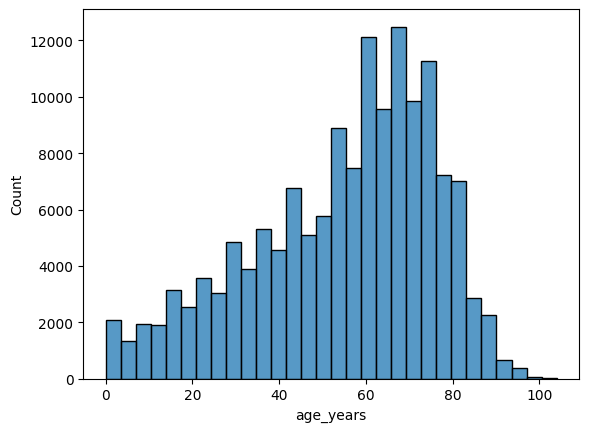

In [140]:
sns.histplot(demo["age_years"], bins=30)
plt.show()

In [135]:
# Checking again for any outliers with age less than 0
demo[demo["age_years"] < 0][["age", "age_cod", "age_years"]]

,age,age_cod,age_years


In [22]:
demo["age_years"].isnull().mean() * 100

np.float64(35.79084047699697)

In [23]:
demo[demo["age_years"].isnull()][
    ["age", "age_cod", "sex", "reporter_country"]
].head(20)

,age,age_cod,sex,reporter_country
4,NaN,NaN,M,TR
5,NaN,NaN,F,TR
13,NaN,NaN,NaN,EU
14,NaN,NaN,F,CA
16,NaN,NaN,F,US
20,NaN,NaN,M,US
21,NaN,NaN,M,US
34,NaN,NaN,M,US
56,NaN,NaN,M,US
72,NaN,NaN,M,US


In [26]:
demo["sex_missing"] = demo["sex"].isnull()

In [27]:
demo["sex"] = demo["sex"].replace({
    "M": "Male",
    "F": "Female"
})

demo["sex"]

,sex
0,Female
1,Male
2,Female
3,Male
4,Male
...,...
230269,Female
230270,Male
230271,Female
230272,Female


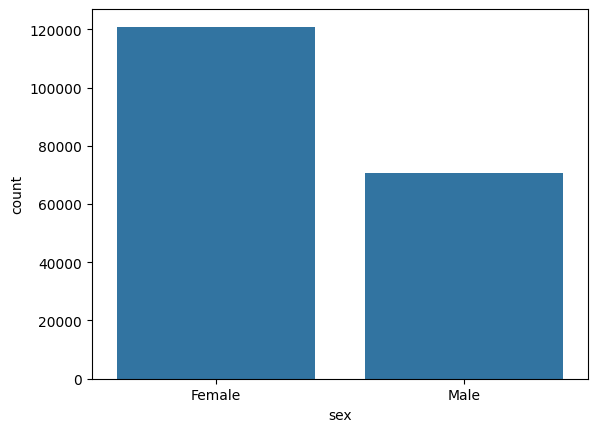

In [28]:
sns.countplot(x="sex", data=demo)
plt.show()

In [29]:

demo.head()

,primaryid,caseid,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,wt,wt_cod,rept_dt,to_mfr,occp_cod,reporter_country,occr_country,age_years,age_missing,sex_missing
0,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,NaN,NaN,20260203.0,NaN,HP,CA,CA,56.0,False,False
1,100293665,10029366.0,5.0,F,NaN,20251229.0,20140322.0,20260106.0,EXP,NaN,...,NaN,NaN,20260106.0,NaN,HP,AU,AU,32.0,False,False
2,1005450711,10054507.0,11.0,F,NaN,20260114.0,20140402.0,20260120.0,PER,NaN,...,NaN,NaN,20260120.0,NaN,MD,US,US,68.0,False,False
3,1005762126,10057621.0,26.0,F,20140204.0,20260112.0,20140404.0,20260127.0,EXP,NaN,...,53.0,KG,20260127.0,NaN,MD,CA,CA,57.0,False,False
4,100670805,10067080.0,5.0,F,NaN,20140428.0,20260119.0,20260119.0,PER,NaN,...,NaN,NaN,20260119.0,NaN,MD,TR,US,NaN,True,False


In [30]:
outc = pd.read_csv(
    "OUTC26Q1.txt",
    sep="$",
    encoding="latin1",
    on_bad_lines="skip"
)



outc.shape

(291580, 3)

In [141]:
outc.columns

Index(['primaryid', 'caseid', 'outc_cod', 'outcome'], dtype='object')

In [32]:
outc.head()

,primaryid,caseid,outc_cod
0,1001678127,10016781,OT
1,100293665,10029366,OT
2,1005762126,10057621,HO
3,100670805,10067080,OT
4,100716524,10071652,OT


In [33]:
outc["outc_cod"].value_counts()

,count
outc_cod,
OT,158154
HO,80509
DE,30927
LT,13222
DS,5935
CA,1517
RI,1316


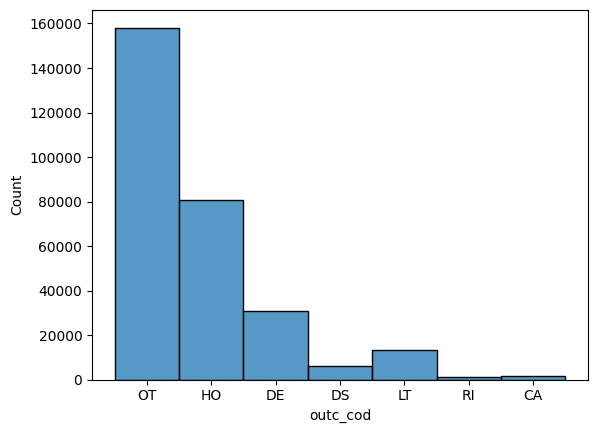

In [34]:
sns.histplot(outc["outc_cod"], bins=30)
plt.show()

In [35]:
outcome_map = {
    "DE": "Death",
    "LT": "Life Threatening",
    "HO": "Hospitalization",
    "DS": "Disability",
    "CA": "Congenital Anomaly",
    "RI": "Required Intervention",
    "OT": "Other Serious Outcome"
}

outc["outcome"] = outc["outc_cod"].map(outcome_map)

In [36]:
outc["outc_cod"].value_counts()

,count
outc_cod,
OT,158154
HO,80509
DE,30927
LT,13222
DS,5935
CA,1517
RI,1316


In [37]:
outc.head()

,primaryid,caseid,outc_cod,outcome
0,1001678127,10016781,OT,Other Serious Outcome
1,100293665,10029366,OT,Other Serious Outcome
2,1005762126,10057621,HO,Hospitalization
3,100670805,10067080,OT,Other Serious Outcome
4,100716524,10071652,OT,Other Serious Outcome


In [38]:
demo_outc = demo.merge(
    outc,
    on="primaryid",
    how="left"
)

In [39]:
demo_outc.head()

,primaryid,caseid_x,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,to_mfr,occp_cod,reporter_country,occr_country,age_years,age_missing,sex_missing,caseid_y,outc_cod,outcome
0,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,NaN,HP,CA,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome
1,100293665,10029366.0,5.0,F,NaN,20251229.0,20140322.0,20260106.0,EXP,NaN,...,NaN,HP,AU,AU,32.0,False,False,10029366.0,OT,Other Serious Outcome
2,1005450711,10054507.0,11.0,F,NaN,20260114.0,20140402.0,20260120.0,PER,NaN,...,NaN,MD,US,US,68.0,False,False,NaN,NaN,NaN
3,1005762126,10057621.0,26.0,F,20140204.0,20260112.0,20140404.0,20260127.0,EXP,NaN,...,NaN,MD,CA,CA,57.0,False,False,10057621.0,HO,Hospitalization
4,100670805,10067080.0,5.0,F,NaN,20140428.0,20260119.0,20260119.0,PER,NaN,...,NaN,MD,TR,US,NaN,True,False,10067080.0,OT,Other Serious Outcome


In [40]:
demo_outc.shape

(277034, 31)

In [41]:
pd.crosstab(
    demo_outc["sex"],
    demo_outc["outcome"]
)

outcome,Congenital Anomaly,Death,Disability,Hospitalization,Life Threatening,Other Serious Outcome,Required Intervention
sex,,,,,,,
Female,607,8051,2034,23014,3818,45372,301
Male,108,8252,1083,18642,3041,31643,202


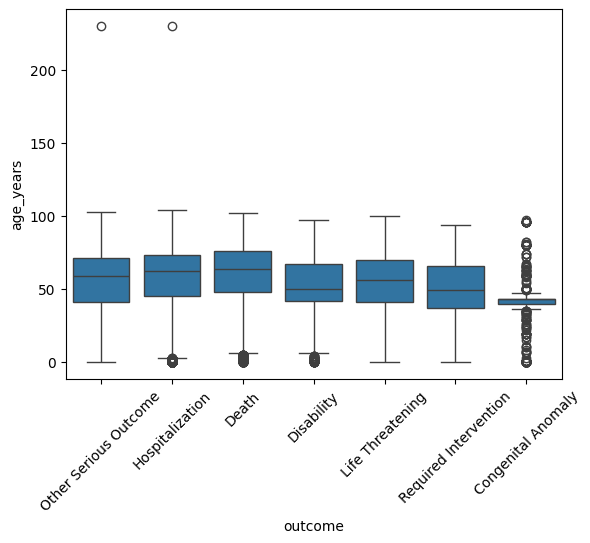

In [42]:
sns.boxplot(
    x="outcome",
    y="age_years",
    data=demo_outc
)

plt.xticks(rotation=45)
plt.show()

In [138]:
demo_outc.groupby("outcome")["reporter_country"] \
    .value_counts() \
    .head(20)

outcome             reporter_country     
Congenital Anomaly  CA                        604
                    EU                        379
                    US                         83
                    GB                         43
                    COUNTRY NOT SPECIFIED      12
                    ZA                         10
                    JP                          8
                    AU                          6
                    CN                          3
                    IL                          2
                    BR                          1
                    CH                          1
                    IN                          1
                    ME                          1
                    PK                          1
                    TR                          1
                    TW                          1
                    ZM                          1
Death               US                       9158
                    EU                       2544
Name: count, dtype: int64

In [137]:
reac = pd.read_csv(
    "REAC26Q1.txt",
    sep="$",
    encoding="latin1",
    on_bad_lines="skip"
)

In [45]:
reac.head(20)

,primaryid,caseid,pt,drug_rec_act
0,1001678127,10016781.0,Erythema,NaN
1,1001678127,10016781.0,Blood creatine increased,NaN
2,1001678127,10016781.0,Fall,NaN
3,1001678127,10016781.0,Scab,NaN
4,1001678127,10016781.0,Rosacea,NaN
5,1001678127,10016781.0,COVID-19,NaN
6,1001678127,10016781.0,Bone pain,NaN
7,1001678127,10016781.0,Pneumonia,NaN
8,1001678127,10016781.0,Metastasis,NaN
9,1001678127,10016781.0,Balance disorder,NaN


In [136]:
demo_reac = demo_outc.merge(
    reac,
    on="primaryid",
    how="left"
)

In [47]:
demo_reac.head()

,primaryid,caseid_x,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,occr_country,age_years,age_missing,sex_missing,caseid_y,outc_cod,outcome,caseid,pt,drug_rec_act
0,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Erythema,NaN
1,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Blood creatine increased,NaN
2,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Fall,NaN
3,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Scab,NaN
4,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Rosacea,NaN


In [48]:
reac["pt"].value_counts().head(20)

,count
pt,
Off label use,15012
Product dose omission issue,11788
Fatigue,10786
Nausea,10679
Drug ineffective,10207
Headache,9200
Diarrhoea,8735
Pain,7297
Dizziness,6727


In [49]:
death_cases = demo_reac[demo_reac["outcome"] == "Death"]

death_cases.head()

,primaryid,caseid_x,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,occr_country,age_years,age_missing,sex_missing,caseid_y,outc_cod,outcome,caseid,pt,drug_rec_act
241,101872822,10187282.0,2.0,F,20140201.0,20260122.0,20140520.0,20260122.0,EXP,NaN,...,NaN,50.0,False,False,10187282.0,DE,Death,10187282.0,Death,NaN
359,103302564,10330256.0,4.0,F,20140401.0,20140805.0,20140721.0,20260127.0,EXP,NaN,...,CA,NaN,True,False,10330256.0,DE,Death,10330256.0,Pneumonia,NaN
360,103302564,10330256.0,4.0,F,20140401.0,20140805.0,20140721.0,20260127.0,EXP,NaN,...,CA,NaN,True,False,10330256.0,DE,Death,10330256.0,Hip fracture,NaN
361,103302564,10330256.0,4.0,F,20140401.0,20140805.0,20140721.0,20260127.0,EXP,NaN,...,CA,NaN,True,False,10330256.0,DE,Death,10330256.0,Sepsis,NaN
362,103302564,10330256.0,4.0,F,20140401.0,20140805.0,20140721.0,20260127.0,EXP,NaN,...,CA,NaN,True,False,10330256.0,DE,Death,10330256.0,Localised infection,NaN


In [50]:
drug = pd.read_csv(
    "DRUG26Q1.txt",
    sep="$",
    encoding="latin1",
    on_bad_lines="skip"
)

In [51]:
drug.head()

,primaryid,caseid,drug_seq,role_cod,drugname,prod_ai,val_vbm,route,dose_vbm,cum_dose_chr,cum_dose_unit,dechal,rechal,lot_num,exp_dt,nda_num,dose_amt,dose_unit,dose_form,dose_freq
0,1001678127,10016781,1,PS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Subcutaneous,"UNK, TID (cont 02 weeks post 01st LAR)",NaN,NaN,Y,U,NaN,NaN,19667.0,NaN,NaN,NaN,TID
1,1001678127,10016781,2,SS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Intramuscular,"20 mg, QMO",NaN,NaN,Y,U,NaN,NaN,19667.0,20.0,MG,NaN,/MONTH
2,1001678127,10016781,3,SS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Intramuscular,"20 mg, QMO",NaN,NaN,Y,U,NaN,NaN,19667.0,20.0,MG,NaN,/MONTH
3,1001678127,10016781,4,SS,SANDOSTATIN LAR DEPOT,OCTREOTIDE ACETATE,1,Intramuscular,"20 mg, QMO (once a month)",NaN,NaN,U,NaN,NaN,NaN,19667.0,20.0,MG,NaN,/MONTH
4,1001678127,10016781,5,SS,SANDOSTATIN LAR DEPOT,OCTREOTIDE ACETATE,1,Intramuscular,"30 mg, QMO (once a month)",NaN,NaN,U,NaN,NaN,NaN,19667.0,30.0,MG,NaN,/MONTH


In [52]:
drug["drugname"].value_counts().head(20)

,count
drugname,
TYMLOS,16191
INFLECTRA,11895
METHOTREXATE,6018
PREDNISONE,5882
ACTEMRA,5704
INFLIXIMAB,4512
RITUXIMAB,4394
DUPIXENT,4084
SULFASALAZINE,3923


In [53]:
drug["role_cod"].value_counts(dropna=False)

,count
role_cod,
SS,181724
C,135516
PS,60030
I,2579
DN,17


# **Module 1 — Demographic Analysis**


# **Q1. Age Distribution of Adverse Event Reports**

Analyze the distribution of patient ages.
Identify the most frequently reported age groups.

In [54]:
# 1) Age distribution of adverse event reports
demo_outc = demo.merge(
    outc,
    on="primaryid",
    how="left"
)

demo_outc.head()

,primaryid,caseid_x,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,to_mfr,occp_cod,reporter_country,occr_country,age_years,age_missing,sex_missing,caseid_y,outc_cod,outcome
0,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,NaN,HP,CA,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome
1,100293665,10029366.0,5.0,F,NaN,20251229.0,20140322.0,20260106.0,EXP,NaN,...,NaN,HP,AU,AU,32.0,False,False,10029366.0,OT,Other Serious Outcome
2,1005450711,10054507.0,11.0,F,NaN,20260114.0,20140402.0,20260120.0,PER,NaN,...,NaN,MD,US,US,68.0,False,False,NaN,NaN,NaN
3,1005762126,10057621.0,26.0,F,20140204.0,20260112.0,20140404.0,20260127.0,EXP,NaN,...,NaN,MD,CA,CA,57.0,False,False,10057621.0,HO,Hospitalization
4,100670805,10067080.0,5.0,F,NaN,20140428.0,20260119.0,20260119.0,PER,NaN,...,NaN,MD,TR,US,NaN,True,False,10067080.0,OT,Other Serious Outcome


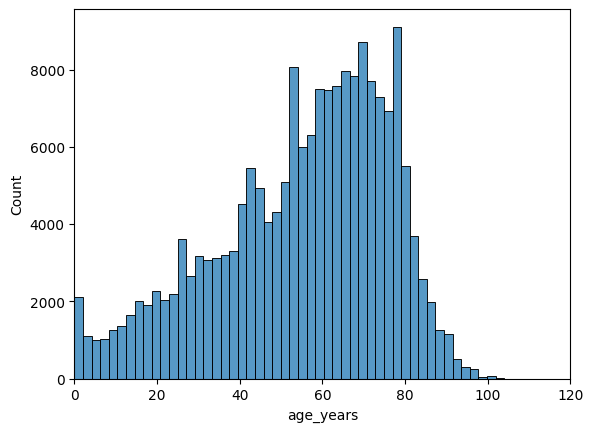

In [55]:
sns.histplot(
    demo_outc[demo_outc["age_years"] <= 120]["age_years"], bins = 50)

plt.xlim(0, 120)

plt.show()


# **Q2. Gender Distribution of Reports**

Compare male vs female report counts.
Visualize overall gender split.

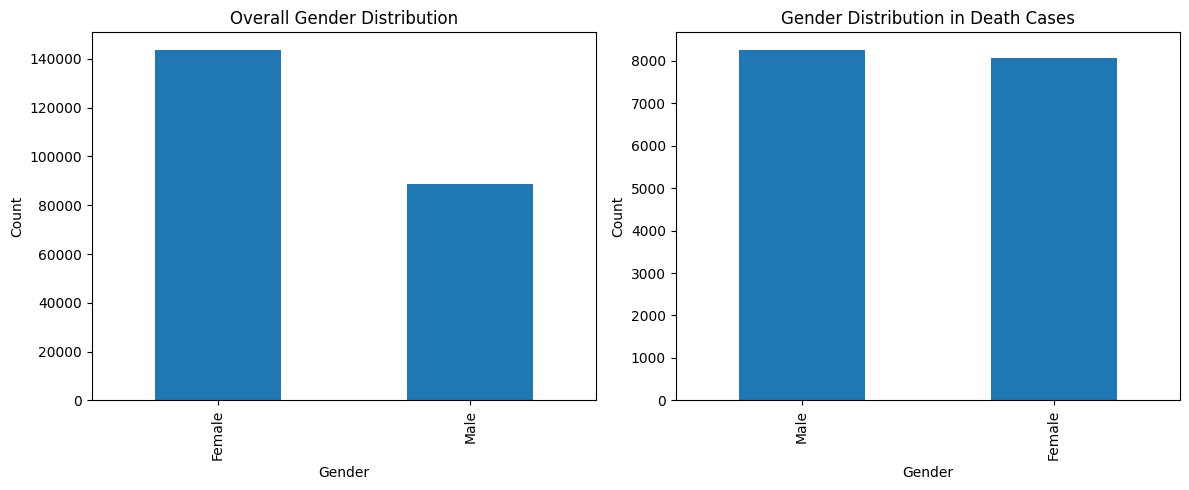

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Overall
demo_outc["sex"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Overall Gender Distribution")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

# Death cases
death_cases["sex"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Gender Distribution in Death Cases")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

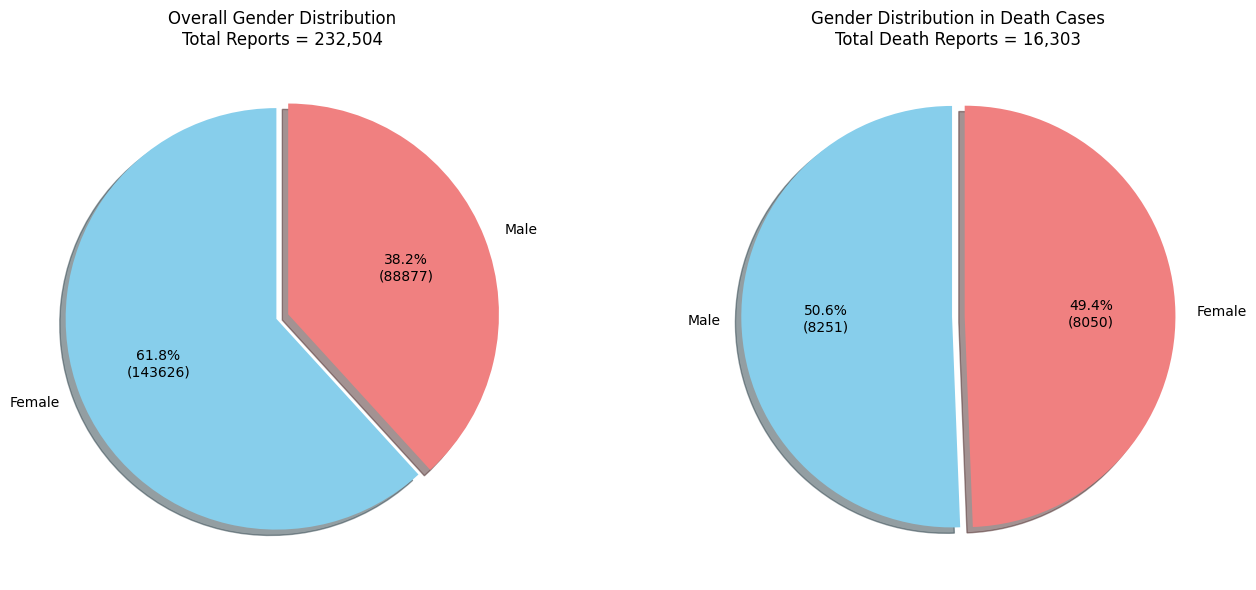

In [143]:
import matplotlib.pyplot as plt

# Overall gender data
overall_counts = demo_outc["sex"].value_counts()

# Death-only gender data
death_cases = demo_outc[
    demo_outc["outcome"] == "Death"
]

death_counts = death_cases["sex"].value_counts()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Overall pie chart

axes[0].pie(
    overall_counts,
    labels=overall_counts.index,
    autopct=lambda p: f"{p:.1f}%\n({int(p * overall_counts.sum() / 100)})",
    startangle=90,
    colors=["skyblue", "lightcoral"],
    explode=(0.03, 0.03),
    shadow=True
)

axes[0].set_title(
    f"Overall Gender Distribution\nTotal Reports = {overall_counts.sum():,}"
)


# Death pie chart

axes[1].pie(
    death_counts,
    labels=death_counts.index,
    autopct=lambda p: f"{p:.1f}%\n({int(p * death_counts.sum() / 100)})",
    startangle=90,
    colors=["skyblue", "lightcoral"],
    explode=(0.03, 0.03),
    shadow=True
)

axes[1].set_title(
    f"Gender Distribution in Death Cases\nTotal Death Reports = {death_counts.sum():,}"
)

plt.tight_layout()

plt.show()

***Female patients account for the majority of overall adverse event reports. However, male representation increases noticeably within death-related cases, suggesting potentially higher severity among reported male adverse events.***


# **Q3. Top 10 Countries by Report Volume**

Identify countries generating the highest number of adverse event reports.

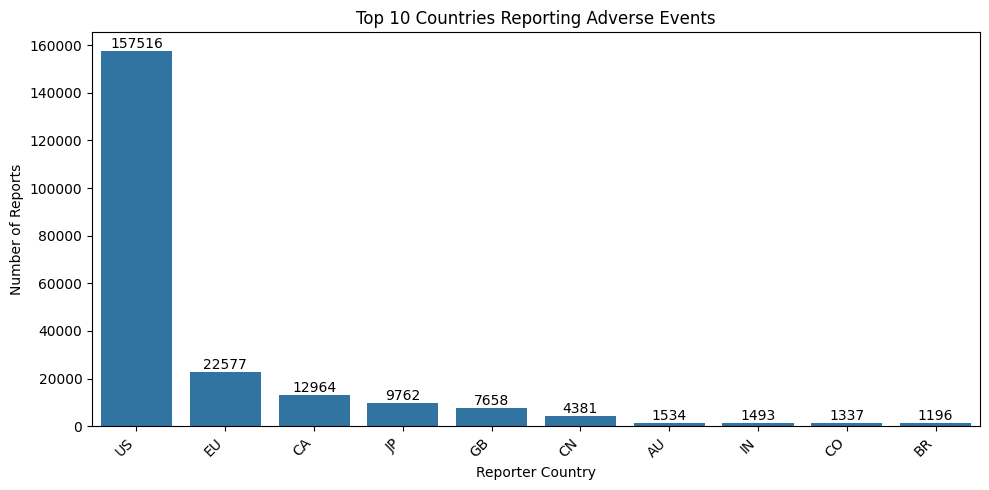

In [60]:
# 3. Top 10 Countries Reporting Adverse Events

import seaborn as sns
import matplotlib.pyplot as plt

# Remove non-informative country values
filtered_demo = demo[
    demo["reporter_country"] != "COUNTRY NOT SPECIFIED"
]

# Get top 10 countries by report count
top_10_countries = (
    filtered_demo["reporter_country"]
    .value_counts()
    .head(10)
    .index
)

# Keep only top 10 countries
filtered_demo_top_10 = filtered_demo[
    filtered_demo["reporter_country"].isin(top_10_countries)
]

# Create figure
plt.figure(figsize=(10, 5))

# Create countplot
ax = sns.countplot(
    x="reporter_country",
    data=filtered_demo_top_10,
    order=top_10_countries
)

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container)

# Titles and labels
plt.title("Top 10 Countries Reporting Adverse Events")
plt.xlabel("Reporter Country")
plt.ylabel("Number of Reports")

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Improve spacing
plt.tight_layout()

# Show chart
plt.show()

# **Q4. Death vs Hospitalization Rate by Age Group**

Compare Death (DE) and Hospitalization (HO) outcomes across age groups.

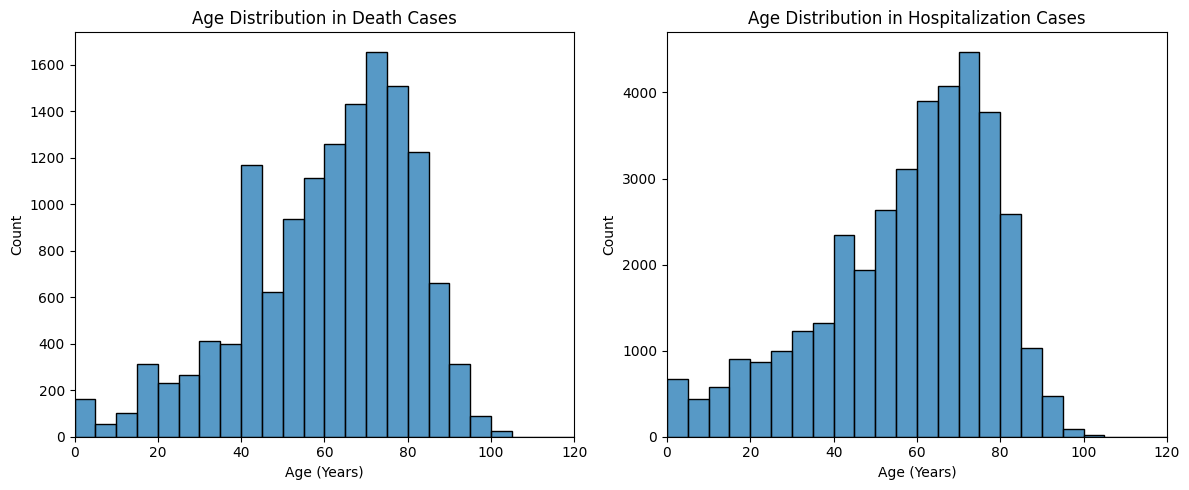

In [144]:
# 4)  Death vs hospitalization rate by age group

import numpy as np



fig, axes = plt.subplots(1, 2, figsize=(12,5))

bins = np.arange(0, 121, 5)

# Death cases (DE)
sns.histplot(
    demo_outc[demo_outc["outc_cod"] == "DE"]["age_years"].dropna(),
    bins=bins,
    ax=axes[0]
)
axes[0].set_xlim(0, 120)

axes[0].set_title("Age Distribution in Death Cases")
axes[0].set_xlabel("Age (Years)")
axes[0].set_ylabel("Count")

# Hospitalization cases (HO)
sns.histplot(
    demo_outc[demo_outc["outc_cod"] == "HO"]["age_years"].dropna(),
    bins=bins,
    ax=axes[1]
)
axes[1].set_xlim(0, 120)

axes[1].set_title("Age Distribution in Hospitalization Cases")
axes[1].set_xlabel("Age (Years)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()



In [62]:

demo_outc["age_years"].describe()


,age_years
count,186206.000000
mean,54.938336
std,21.019793
min,0.000000
25%,41.000000
50%,59.000000
75%,71.000000
max,230.000000


In [63]:
demo_outc["age_years"].sort_values(ascending=False).head(20)

,age_years
167547,230.0
167546,230.0
196334,104.0
67634,103.0
67633,103.0
16578,102.0
117041,102.0
117042,102.0
276409,102.0
150628,102.0


# **Q5. Severe Outcome Percentage by Age Group**

Determine which age groups experience the highest proportion of severe outcomes.

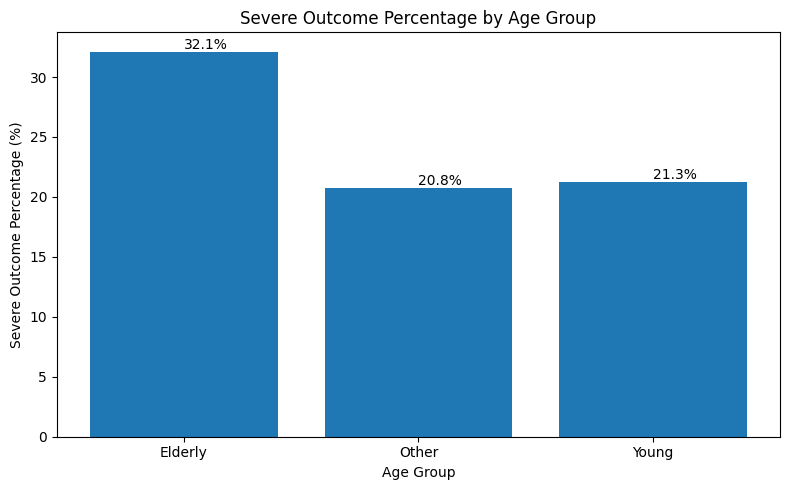

In [147]:
demo_outc['age_group'] = np.where(
    demo_outc['age_years'] < 40,  'Young',
    np.where(
        demo_outc['age_years'] >= 65,  'Elderly', 'Other'
    )
)

severe = demo_outc[
    demo_outc['outc_cod'].isin(['DE', 'HO'])
]

severe_pct = (
    severe.groupby('age_group')['primaryid'].count()
    /
    demo_outc.groupby('age_group')['primaryid'].count()
    * 100
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    severe_pct.index,
    severe_pct.values
)

plt.title('Severe Outcome Percentage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Severe Outcome Percentage (%)')

for i, v in enumerate(severe_pct.values):
    plt.text(i, v + 0.2, f'{v:.1f}%')

plt.tight_layout()
plt.show()

# **Module 2 — Reactions**


In [66]:
reac = pd.read_csv("REAC26Q1.txt", sep = "$", encoding = "latin", on_bad_lines="skip")

reac.head()



,primaryid,caseid,pt,drug_rec_act
0,1001678127,10016781.0,Erythema,NaN
1,1001678127,10016781.0,Blood creatine increased,NaN
2,1001678127,10016781.0,Fall,NaN
3,1001678127,10016781.0,Scab,NaN
4,1001678127,10016781.0,Rosacea,NaN


In [67]:
top20 = (
    reac['pt']
    .value_counts()
    .head(20)
)

top20.head()

,count
pt,
Off label use,15012
Product dose omission issue,11788
Fatigue,10786
Nausea,10679
Drug ineffective,10207


# **Q1. Top 20 Most Reported Reactions**

Identify the most frequently reported adverse reactions.

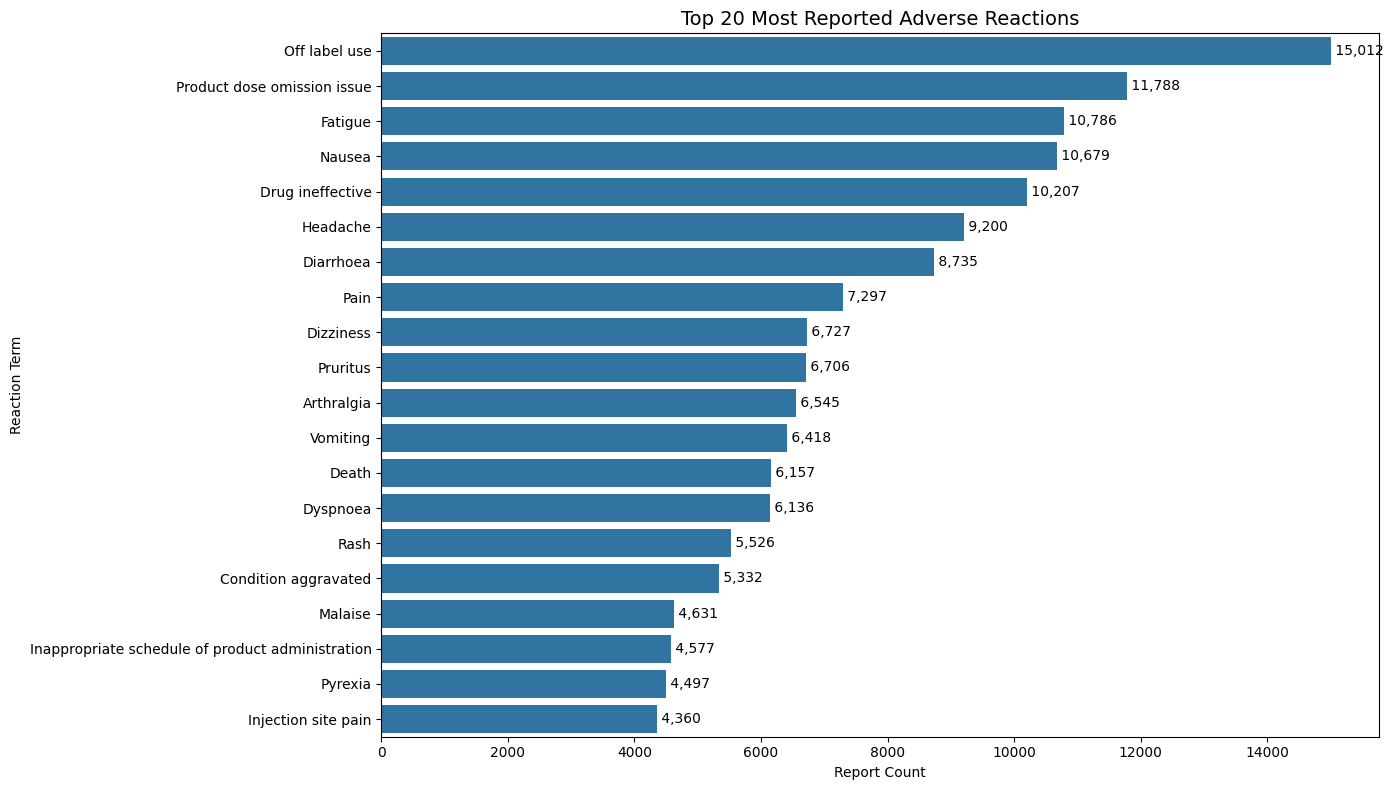

In [69]:
plt.figure(figsize=(14,8))

sns.barplot(
    x=top20.values,
    y=top20.index
)

plt.title('Top 20 Most Reported Adverse Reactions', fontsize=14)
plt.xlabel('Report Count')
plt.ylabel('Reaction Term')

for i, v in enumerate(top20.values):
    plt.text(v, i, f' {v:,}', va='center')

plt.tight_layout()
plt.show()

In [70]:
# step 1 - keeping only death cases

death_outcomes = outc[outc['outc_cod']  == 'DE']


In [71]:
# step 2 - Join with reactions

death_reactions = reac.merge(
    death_outcomes[['primaryid']],
    on = 'primaryid',
    how = 'inner'
)

death_reactions = death_reactions[
    death_reactions['pt'] != 'Death'
]

In [72]:
top_death_reactions = (
    death_reactions['pt']
    .value_counts()
    .head(20)
)

top_death_reactions

,count
pt,
Completed suicide,1375
Off label use,1112
Toxicity to various agents,1047
Drug ineffective,754
Pneumonia,721
Pyrexia,610
Fatigue,567
Dyspnoea,562
Diarrhoea,561


# **Q2. Reactions Most Frequently Associated with Death**

Among death outcome reports, find the reactions reported most often.

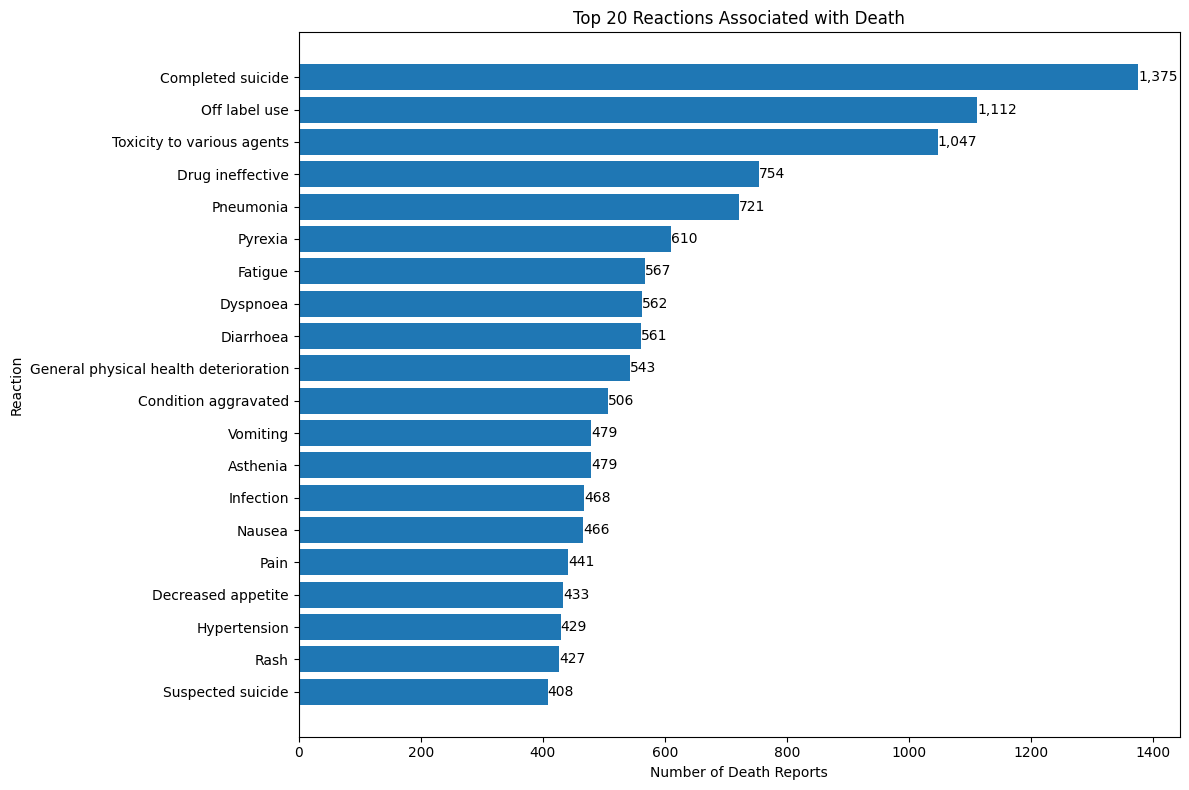

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    top_death_reactions.index,
    top_death_reactions.values
)

plt.title('Top 20 Reactions Associated with Death')
plt.xlabel('Number of Death Reports')
plt.ylabel('Reaction')

plt.gca().invert_yaxis()

for i, v in enumerate(top_death_reactions.values):
    plt.text(v, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

In [74]:
hospitalization = outc[outc['outc_cod']  == 'HO']

In [75]:
hosp_outcomes = reac.merge(
    hospitalization[['primaryid']],
    on = 'primaryid',
    how = 'inner'
)

In [76]:
top_hosp_reactions = hosp_outcomes['pt'].value_counts().head(20)

top_hosp_reactions.head(20)

,count
pt,
Off label use,3872
Nausea,3204
Diarrhoea,3086
Vomiting,2996
Pneumonia,2674
Fatigue,2550
Dyspnoea,2485
Drug ineffective,2298
Pyrexia,2278


# **Q3. Reactions Most Frequently Associated with Hospitalization**

Among hospitalization reports, identify the most common reactions.

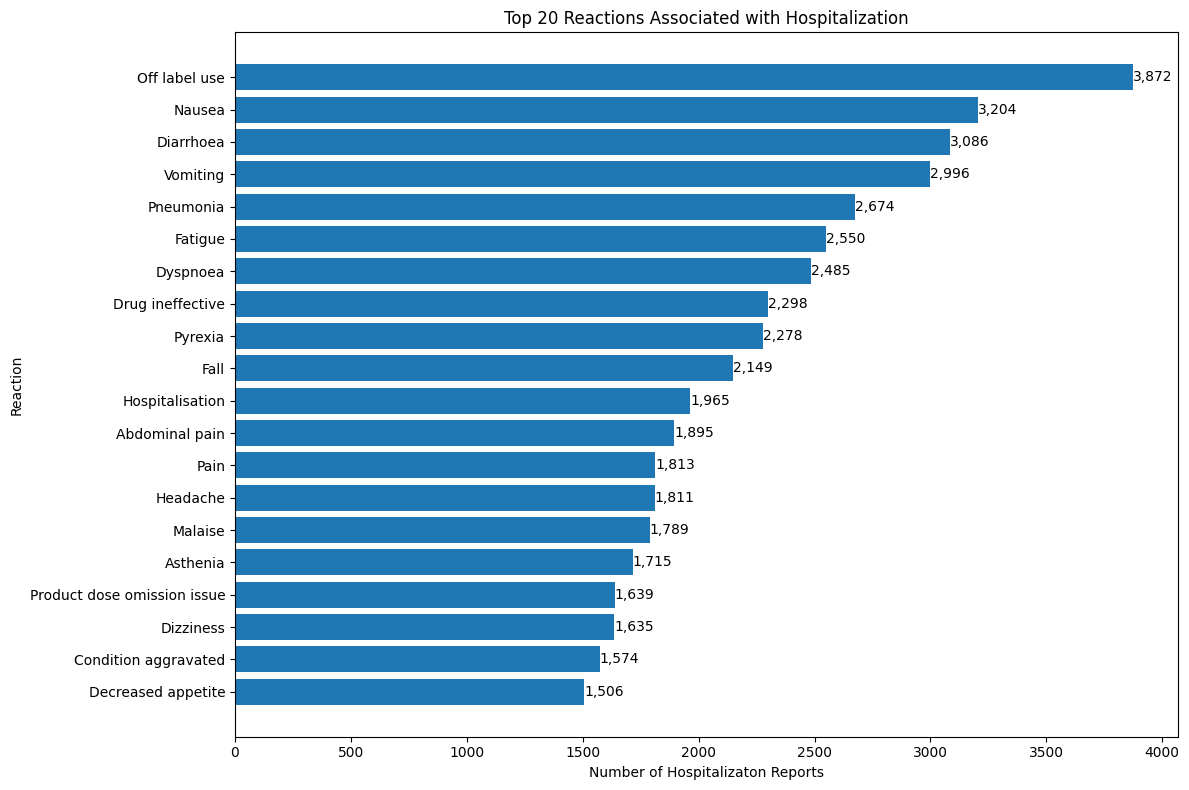

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    top_hosp_reactions.index,
    top_hosp_reactions.values
)

plt.title('Top 20 Reactions Associated with Hospitalization')
plt.xlabel('Number of Hospitalizaton Reports')
plt.ylabel('Reaction')

plt.gca().invert_yaxis()

for i, v in enumerate(top_hosp_reactions.values):
    plt.text(v, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

In [78]:
demo_reac[['age_years', "primaryid","pt"]].head()

,age_years,primaryid,pt
0,56.0,1001678127,Erythema
1,56.0,1001678127,Blood creatine increased
2,56.0,1001678127,Fall
3,56.0,1001678127,Scab
4,56.0,1001678127,Rosacea


In [79]:
reac_demo = demo_reac.copy()

reac_demo.head()

,primaryid,caseid_x,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,occr_country,age_years,age_missing,sex_missing,caseid_y,outc_cod,outcome,caseid,pt,drug_rec_act
0,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Erythema,NaN
1,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Blood creatine increased,NaN
2,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Fall,NaN
3,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Scab,NaN
4,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Rosacea,NaN


In [80]:
reac_demo['age_group'] = np.where(
    reac_demo['age_years'] < 40,  'Young',
    np.where(
        reac_demo['age_years'] >= 65,  'Elderly', 'Other'
    )
)

In [81]:
reac_demo['age_years'].describe()

,age_years
count,965585.000000
mean,52.589669
std,19.260844
min,0.000000
25%,43.000000
50%,53.000000
75%,68.000000
max,230.000000


In [82]:
reac_demo['age_years'].isna().sum()

np.int64(290447)

In [83]:
reac_demo['age_group'].value_counts()

,count
age_group,
Other,782372
Elderly,297790
Young,175870


In [84]:
comparison = reac_demo[
    reac_demo['age_group'].isin(['Young', 'Elderly'])
]

comparison.head()

,primaryid,caseid_x,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,age_years,age_missing,sex_missing,caseid_y,outc_cod,outcome,caseid,pt,drug_rec_act,age_group
77,100293665,10029366.0,5.0,F,NaN,20251229.0,20140322.0,20260106.0,EXP,NaN,...,32.0,False,False,10029366.0,OT,Other Serious Outcome,10029366.0,Peripheral swelling,NaN,Young
78,100293665,10029366.0,5.0,F,NaN,20251229.0,20140322.0,20260106.0,EXP,NaN,...,32.0,False,False,10029366.0,OT,Other Serious Outcome,10029366.0,Sinusitis,NaN,Young
79,100293665,10029366.0,5.0,F,NaN,20251229.0,20140322.0,20260106.0,EXP,NaN,...,32.0,False,False,10029366.0,OT,Other Serious Outcome,10029366.0,Toxicity to various agents,NaN,Young
80,100293665,10029366.0,5.0,F,NaN,20251229.0,20140322.0,20260106.0,EXP,NaN,...,32.0,False,False,10029366.0,OT,Other Serious Outcome,10029366.0,Iritis,NaN,Young
81,100293665,10029366.0,5.0,F,NaN,20251229.0,20140322.0,20260106.0,EXP,NaN,...,32.0,False,False,10029366.0,OT,Other Serious Outcome,10029366.0,Arthralgia,NaN,Young


In [85]:
comparison.groupby(
    ['age_group', 'pt']
)['primaryid'].count()

age_group  pt                              
Elderly    17-hydroxyprogesterone increased    3
           3M syndrome                         1
           ADAMTS13 activity decreased         1
           AGEP-DRESS overlap                  3
           AST/ALT ratio increased             1
                                              ..
Young      Yawning                             2
           Yellow skin                         9
           Zinc deficiency                     1
           pH urine decreased                  1
           pH urine increased                  1
Name: primaryid, Length: 12385, dtype: int64

In [86]:
reaction_counts = (
    comparison
    .groupby(['age_group', 'pt'])['primaryid']
    .count()
    .reset_index(name='count')
)

In [87]:
reaction_counts.head()

,age_group,pt,count
0,Elderly,17-hydroxyprogesterone increased,3
1,Elderly,3M syndrome,1
2,Elderly,ADAMTS13 activity decreased,1
3,Elderly,AGEP-DRESS overlap,3
4,Elderly,AST/ALT ratio increased,1


In [88]:
reaction_counts.sort_values(
    'count',
    ascending=False
).head(20)

,age_group,pt,count
4270,Elderly,Off label use,4716
1550,Elderly,Death,4270
10339,Young,Off label use,4015
2208,Elderly,Fatigue,3821
1694,Elderly,Diarrhoea,3480
4063,Elderly,Nausea,3410
1862,Elderly,Dyspnoea,2882
4711,Elderly,Pneumonia,2794
2195,Elderly,Fall,2780
1787,Elderly,Drug ineffective,2733


In [89]:
elderly_top10 = (
    reaction_counts[
        reaction_counts['age_group'] == 'Elderly'
    ]
    .sort_values(by='count', ascending=False)
    .head(10)
)

young_top10 = (
    reaction_counts[
        reaction_counts['age_group'] == 'Young'
    ]
    .sort_values(by='count', ascending=False)
    .head(10)
)

In [90]:


young_top10.head()

,age_group,pt,count
10339,Young,Off label use,4015
8060,Young,Drug ineffective,2146
10942,Young,Product dose omission issue,1847
7683,Young,Complication of device insertion,1759
12309,Young,Vomiting,1675


In [91]:
elderly_top10.head()

,age_group,pt,count
4270,Elderly,Off label use,4716
1550,Elderly,Death,4270
2208,Elderly,Fatigue,3821
1694,Elderly,Diarrhoea,3480
4063,Elderly,Nausea,3410


# **Q4. Reaction Patterns in Young vs Elderly Patients**
Young Patients (< 40 years)
Elderly Patients (≥ 65 years)
Compare the top reactions between the two groups.

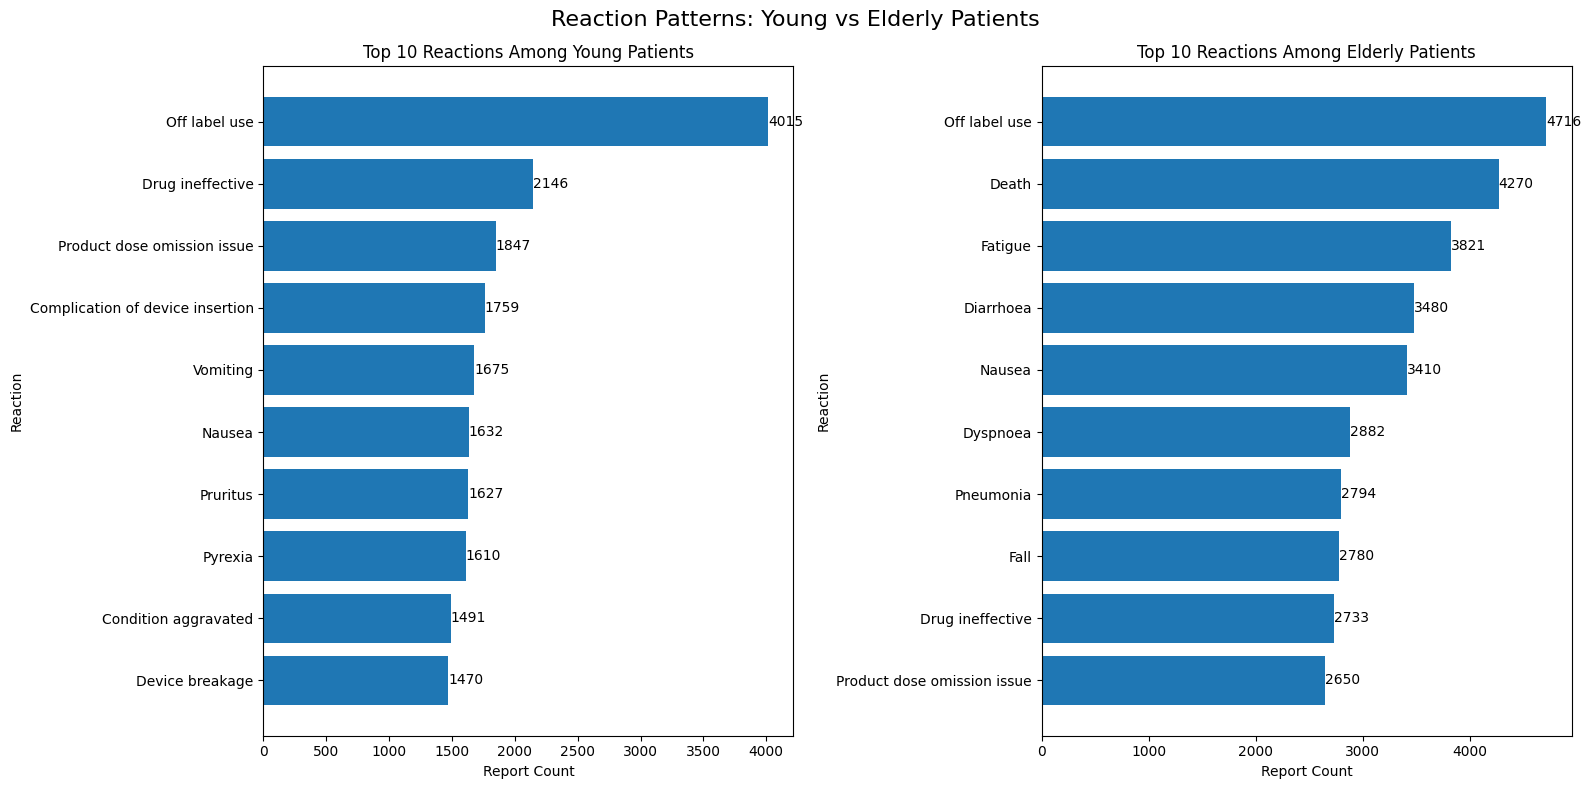

In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Young Patients
axes[0].barh(
    young_top10['pt'],
    young_top10['count']
)

axes[0].set_title('Top 10 Reactions Among Young Patients')
axes[0].set_xlabel('Report Count')
axes[0].set_ylabel('Reaction')
axes[0].invert_yaxis()

for i, v in enumerate(young_top10['count']):
    axes[0].text(v , i, str(v), va='center')


# Elderly Patients
axes[1].barh(
    elderly_top10['pt'],
    elderly_top10['count']
)

axes[1].set_title('Top 10 Reactions Among Elderly Patients')
axes[1].set_xlabel('Report Count')
axes[1].set_ylabel('Reaction')
axes[1].invert_yaxis()

for i, v in enumerate(elderly_top10['count']):
    axes[1].text(v, i, str(v), va='center')


plt.suptitle(
    'Reaction Patterns: Young vs Elderly Patients',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [93]:
top_5 = demo_reac['pt'].value_counts().head(5)
top_5.head()

,count
pt,
Off label use,20364
Nausea,14455
Fatigue,14417
Drug ineffective,13748
Product dose omission issue,12991


In [94]:
top_5_reac = demo_reac[demo_reac['pt'].isin(top_5.index)]

top_5_reac.head()

,primaryid,caseid_x,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,occr_country,age_years,age_missing,sex_missing,caseid_y,outc_cod,outcome,caseid,pt,drug_rec_act
20,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Fatigue,NaN
31,1001678127,10016781.0,27.0,F,20120330.0,20260121.0,20140318.0,20260203.0,EXP,NaN,...,CA,56.0,False,False,10016781.0,OT,Other Serious Outcome,10016781.0,Nausea,NaN
112,1005762126,10057621.0,26.0,F,20140204.0,20260112.0,20140404.0,20260127.0,EXP,NaN,...,CA,57.0,False,False,10057621.0,HO,Hospitalization,10057621.0,Off label use,NaN
120,1005762126,10057621.0,26.0,F,20140204.0,20260112.0,20140404.0,20260127.0,EXP,NaN,...,CA,57.0,False,False,10057621.0,HO,Hospitalization,10057621.0,Fatigue,NaN
160,1007844154,10078441.0,54.0,F,20130101.0,20160607.0,20140415.0,20260325.0,EXP,NaN,...,CA,65.0,False,False,10078441.0,OT,Other Serious Outcome,10078441.0,Nausea,NaN


In [95]:
country_comparison = top_5_reac.groupby(['occr_country', 'pt'])['primaryid'].count()

In [96]:
country_comparison.head()

occr_country  pt              
A1            Drug ineffective    1
AE            Drug ineffective    4
              Fatigue             6
              Nausea              1
              Off label use       5
Name: primaryid, dtype: int64

In [97]:
country_comparison = (
    top_5_reac
    .groupby(['occr_country', 'pt'])['primaryid']
    .count()
    .reset_index(name='count')
)

In [98]:
top10_country_reactions = (
    country_comparison
    .sort_values('count', ascending=False)
    .head(10)
)

# **Q5. Country-wise Analysis of Top Reactions**
For the top reported reactions, identify which countries contribute the most reports.

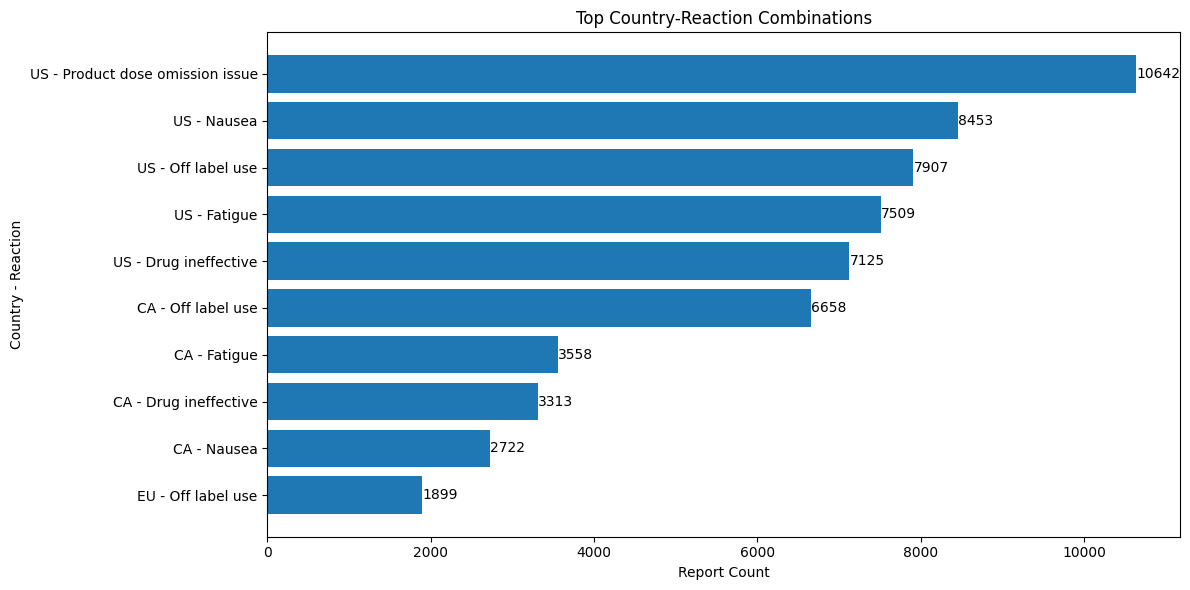

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    top10_country_reactions['occr_country'] + ' - ' + top10_country_reactions['pt'],
    top10_country_reactions['count']
)

plt.title('Top Country-Reaction Combinations')
plt.xlabel('Report Count')
plt.ylabel('Country - Reaction')

plt.gca().invert_yaxis()

for i, v in enumerate(top10_country_reactions['count']):
    plt.text(v + 5, i, str(v), va='center')

plt.tight_layout()
plt.show()

In [100]:
pivot = country_comparison.pivot(
    index='occr_country',
    columns='pt',
    values='count'
).fillna(0)

pivot.head()

pt,Drug ineffective,Fatigue,Nausea,Off label use,Product dose omission issue
occr_country,,,,,
A1,1.0,0.0,0.0,0.0,0.0
AE,4.0,6.0,1.0,5.0,6.0
AI,1.0,0.0,0.0,0.0,0.0
AL,0.0,0.0,0.0,2.0,0.0
AR,20.0,31.0,29.0,33.0,23.0


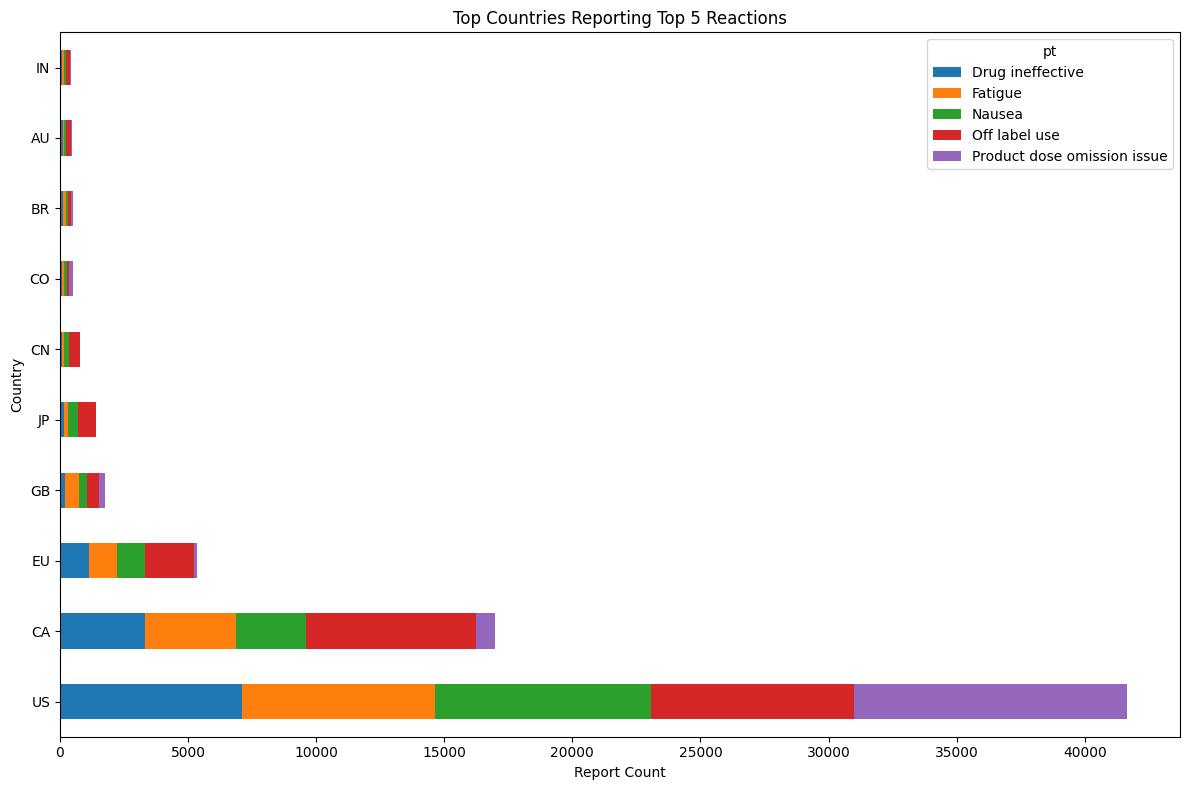

In [101]:
pivot = pivot.loc[
    pivot.sum(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
]

pivot.plot(
    kind='barh',
    stacked=True,
    figsize=(12,8)
)

plt.title('Top Countries Reporting Top 5 Reactions')
plt.xlabel('Report Count')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

# **Module 3 — Drug Risk Analysis**

In [102]:
drug = pd.read_csv("DRUG26Q1.txt", sep = "$", encoding = "latin", on_bad_lines="skip")

drug.head()

,primaryid,caseid,drug_seq,role_cod,drugname,prod_ai,val_vbm,route,dose_vbm,cum_dose_chr,cum_dose_unit,dechal,rechal,lot_num,exp_dt,nda_num,dose_amt,dose_unit,dose_form,dose_freq
0,1001678127,10016781,1,PS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Subcutaneous,"UNK, TID (cont 02 weeks post 01st LAR)",NaN,NaN,Y,U,NaN,NaN,19667.0,NaN,NaN,NaN,TID
1,1001678127,10016781,2,SS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Intramuscular,"20 mg, QMO",NaN,NaN,Y,U,NaN,NaN,19667.0,20.0,MG,NaN,/MONTH
2,1001678127,10016781,3,SS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Intramuscular,"20 mg, QMO",NaN,NaN,Y,U,NaN,NaN,19667.0,20.0,MG,NaN,/MONTH
3,1001678127,10016781,4,SS,SANDOSTATIN LAR DEPOT,OCTREOTIDE ACETATE,1,Intramuscular,"20 mg, QMO (once a month)",NaN,NaN,U,NaN,NaN,NaN,19667.0,20.0,MG,NaN,/MONTH
4,1001678127,10016781,5,SS,SANDOSTATIN LAR DEPOT,OCTREOTIDE ACETATE,1,Intramuscular,"30 mg, QMO (once a month)",NaN,NaN,U,NaN,NaN,NaN,19667.0,30.0,MG,NaN,/MONTH


In [103]:
drug['prod_ai'].isna().sum()


np.int64(6316)

In [104]:
drug_clean = drug.dropna(subset=['prod_ai'])

In [105]:
top_20_drugs  = drug_clean['prod_ai'].value_counts().head(20)

top_20_drugs.head(20)

,count
prod_ai,
ABALOPARATIDE,16197
INFLIXIMAB-DYYB,11978
TOCILIZUMAB,6767
INFLIXIMAB,6130
METHOTREXATE,6022
PREDNISONE,5896
RITUXIMAB,4695
ACETAMINOPHEN,4281
DUPILUMAB,4161


# **Q1. Top 20 Drugs by Adverse Event Reports**
Identify drugs appearing most frequently in adverse event reports.

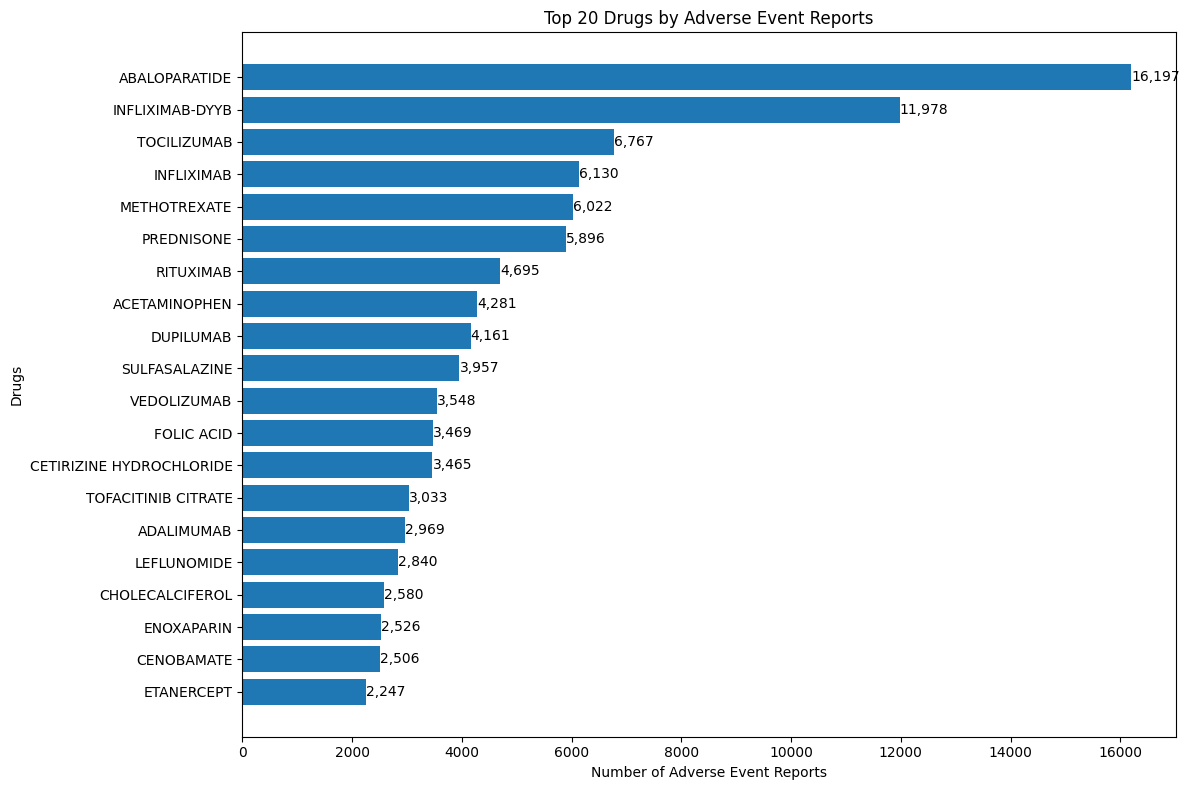

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    top_20_drugs.index,
    top_20_drugs.values
)

plt.title('Top 20 Drugs by Adverse Event Reports')
plt.xlabel('Number of Adverse Event Reports')
plt.ylabel('Drugs')

plt.gca().invert_yaxis()

for i, v in enumerate(top_20_drugs.values):
    plt.text(v, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

In [107]:
# Q2 Top Drugs Associated with Death

drug = pd.read_csv("DRUG26Q1.txt", sep = "$", encoding = "latin", on_bad_lines="skip")


drug_outc = drug.merge(
    outc,
    on = 'primaryid',
    how = 'inner'
)

drug_outc['outc_cod'].head()

,outc_cod
0,OT
1,OT
2,OT
3,OT
4,OT


In [108]:
drug_deaths = drug_outc[drug_outc['outc_cod'] == 'DE']
drug_deaths.head()

,primaryid,caseid_x,drug_seq,role_cod,drugname,prod_ai,val_vbm,route,dose_vbm,cum_dose_chr,...,lot_num,exp_dt,nda_num,dose_amt,dose_unit,dose_form,dose_freq,caseid_y,outc_cod,outcome
134,101872822,10187282,1,PS,CITALOPRAM HYDROBROMIDE,CITALOPRAM HYDROBROMIDE,1,Topical,"1 dosage form, total",NaN,...,NaN,NaN,77031.0,NaN,NaN,NaN,NaN,10187282,DE,Death
219,103302564,10330256,1,PS,ACTEMRA,TOCILIZUMAB,1,Intravenous (not otherwise specified),NaN,NaN,...,B20293,NaN,NaN,284.0,MG,NaN,NaN,10330256,DE,Death
221,103302564,10330256,1,PS,ACTEMRA,TOCILIZUMAB,1,Intravenous (not otherwise specified),NaN,NaN,...,B20353,NaN,NaN,568.0,MG,Solution for infusion,NaN,10330256,DE,Death
223,103302564,10330256,2,C,PREDNISONE,PREDNISONE,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10330256,DE,Death
225,103302564,10330256,3,C,LEVOTHYROXINE,LEVOTHYROXINE,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10330256,DE,Death


In [109]:
# Top Drugs Associated with Death

deaths_by_drug = drug_deaths['prod_ai'].value_counts().head(20)

deaths_by_drug.head()

,count
prod_ai,
TOCILIZUMAB,3714
METHOTREXATE,3686
SULFASALAZINE,3141
PREDNISONE,2428
FOLIC ACID,2183


# **Q2. Drugs Most Frequently Associated with Death**
Determine which drugs occur most often in death-related reports.

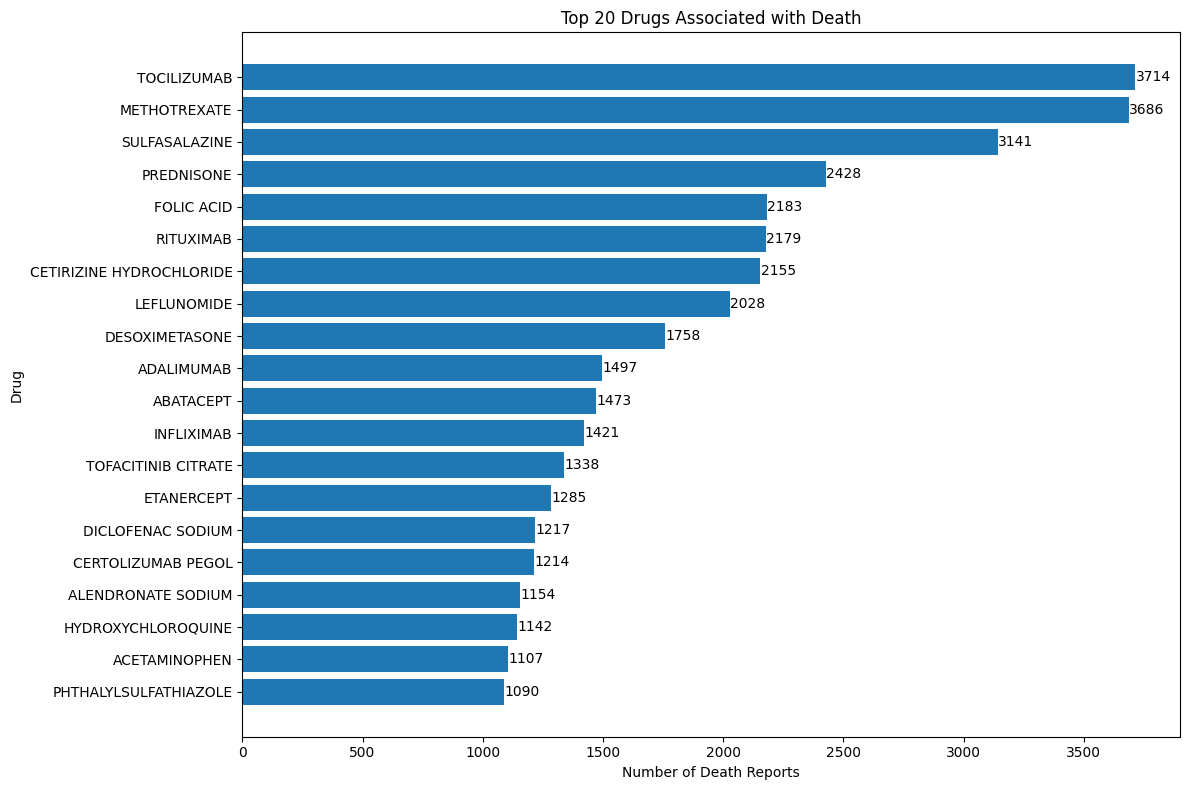

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    deaths_by_drug.index,
    deaths_by_drug.values
)

plt.title('Top 20 Drugs Associated with Death')
plt.xlabel('Number of Death Reports')
plt.ylabel('Drug')

plt.gca().invert_yaxis()

for i, v in enumerate(deaths_by_drug.values):
    plt.text(v + 1, i, str(v), va='center')

plt.tight_layout()
plt.show()

In [111]:
# Q3 Top drugs associated with hospitalization

hosp_deaths = drug_outc[drug_outc['outc_cod'] == 'HO']
hosp_deaths.head()

,primaryid,caseid_x,drug_seq,role_cod,drugname,prod_ai,val_vbm,route,dose_vbm,cum_dose_chr,...,lot_num,exp_dt,nda_num,dose_amt,dose_unit,dose_form,dose_freq,caseid_y,outc_cod,outcome
46,1005762126,10057621,1,PS,XOLAIR,OMALIZUMAB,1,Subcutaneous,NaN,NaN,...,ST709,NaN,103976.0,375.0,MG,"INJECTION, SOLUTION",Q3W,10057621,HO,Hospitalization
47,1005762126,10057621,1,PS,XOLAIR,OMALIZUMAB,1,NaN,NaN,NaN,...,SJY86,NaN,103976.0,NaN,NaN,NaN,NaN,10057621,HO,Hospitalization
48,1005762126,10057621,1,PS,XOLAIR,OMALIZUMAB,1,Subcutaneous,NaN,NaN,...,SJY86,NaN,103976.0,225.0,MG,"INJECTION, SOLUTION",NaN,10057621,HO,Hospitalization
49,1005762126,10057621,1,PS,XOLAIR,OMALIZUMAB,1,Subcutaneous,NaN,NaN,...,NaN,NaN,103976.0,150.0,MG,"INJECTION, SOLUTION",NaN,10057621,HO,Hospitalization
50,1005762126,10057621,1,PS,XOLAIR,OMALIZUMAB,1,Subcutaneous,NaN,NaN,...,S0068D,NaN,103976.0,NaN,NaN,"INJECTION, SOLUTION",NaN,10057621,HO,Hospitalization


In [112]:
hosp_by_drug = hosp_deaths['prod_ai'].value_counts().head(20)
hosp_by_drug.head()

,count
prod_ai,
METHOTREXATE,4509
TOCILIZUMAB,3840
PREDNISONE,3801
INFLIXIMAB-DYYB,3553
SULFASALAZINE,3188


# **Q3. Drugs Most Frequently Associated with Hospitalization**
Determine which drugs occur most often in hospitalization-related reports.

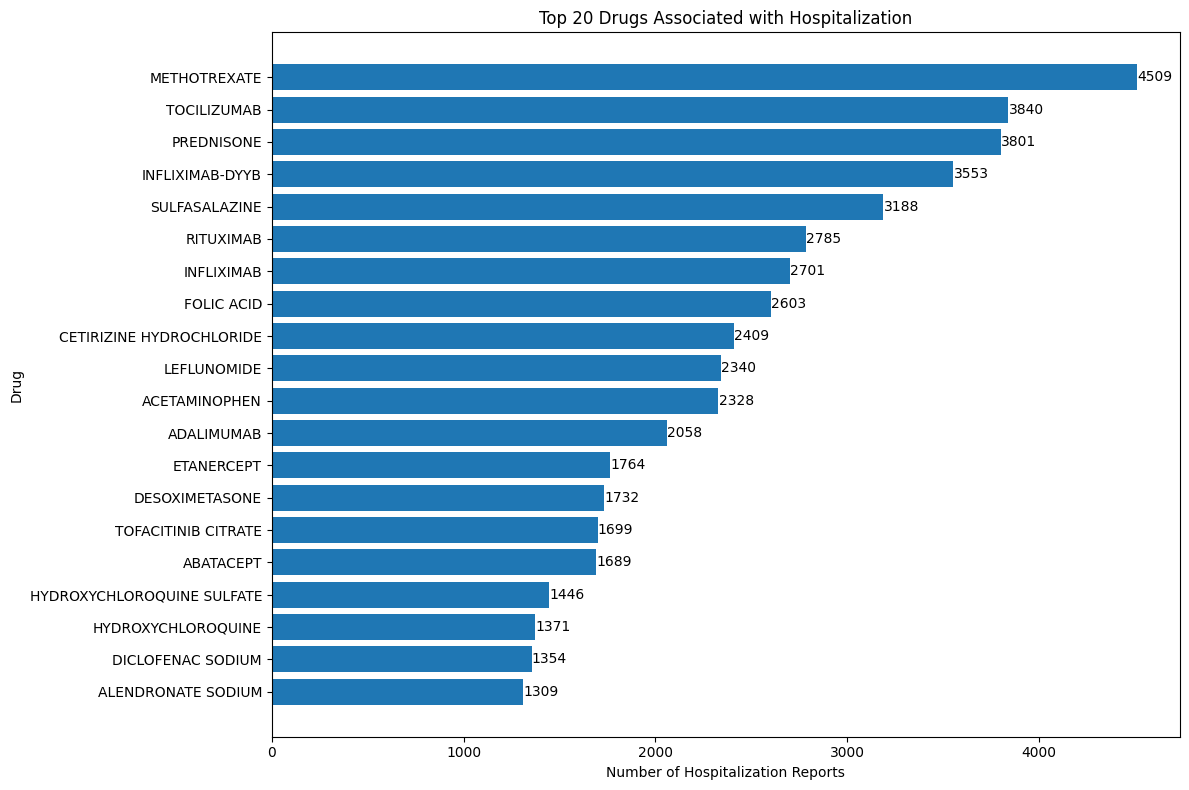

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    hosp_by_drug.index,
    hosp_by_drug.values
)

plt.title('Top 20 Drugs Associated with Hospitalization')
plt.xlabel('Number of Hospitalization Reports')
plt.ylabel('Drug')

plt.gca().invert_yaxis()

for i, v in enumerate(hosp_by_drug.values):
    plt.text(v + 1, i, str(v), va='center')

plt.tight_layout()
plt.show()

In [114]:
# Q4. Drug Role Distribution

drug['role_cod'].value_counts()

,count
role_cod,
SS,181724
C,135516
PS,60030
I,2579
DN,17


In [115]:
role_counts = drug['role_cod'].value_counts()

role_map = {
    'PS': 'Primary Suspect',
    'SS': 'Secondary Suspect',
    'C': 'Concomitant',
    'I': 'Interacting',
    'DN': 'Do Not Know'
}

role_counts.index = role_counts.index.map(role_map)

# **Q4. Drug Role Distribution**
Analyze:
Primary Suspect (PS)
Secondary Suspect (SS)
Concomitant (C)
Interacting (I)
Compare their distribution across reports.

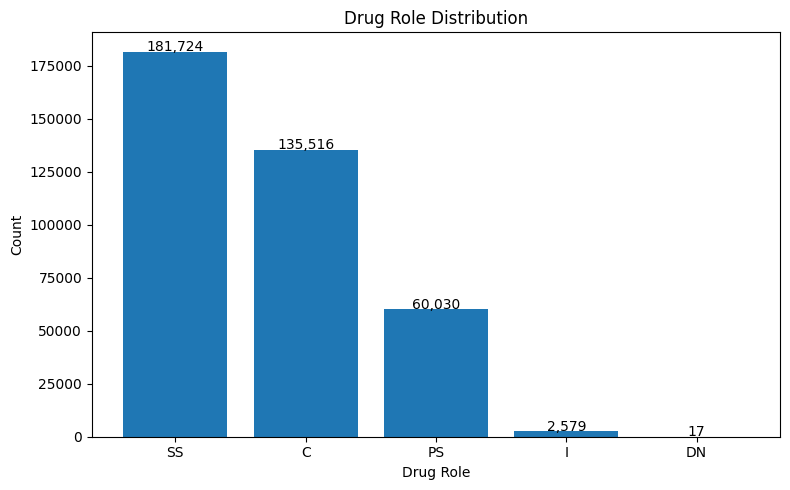

In [117]:
plt.figure(figsize=(8,5))

plt.bar(
    role_counts.index,
    role_counts.values
)

plt.title('Drug Role Distribution')
plt.xlabel('Drug Role')
plt.ylabel('Count')

for i, v in enumerate(role_counts.values):
    plt.text(i, v + 100, f'{v:,}', ha='center')

plt.tight_layout()
plt.show()

In [119]:
#  Q5 — Top Drug–Reaction Pairs
drug_reac = drug.merge(
    reac,
    on = 'primaryid',
    how = 'inner'
)

drug_reac.head()


,primaryid,caseid_x,drug_seq,role_cod,drugname,prod_ai,val_vbm,route,dose_vbm,cum_dose_chr,...,lot_num,exp_dt,nda_num,dose_amt,dose_unit,dose_form,dose_freq,caseid_y,pt,drug_rec_act
0,1001678127,10016781,1,PS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Subcutaneous,"UNK, TID (cont 02 weeks post 01st LAR)",NaN,...,NaN,NaN,19667.0,NaN,NaN,NaN,TID,10016781.0,Erythema,NaN
1,1001678127,10016781,1,PS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Subcutaneous,"UNK, TID (cont 02 weeks post 01st LAR)",NaN,...,NaN,NaN,19667.0,NaN,NaN,NaN,TID,10016781.0,Blood creatine increased,NaN
2,1001678127,10016781,1,PS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Subcutaneous,"UNK, TID (cont 02 weeks post 01st LAR)",NaN,...,NaN,NaN,19667.0,NaN,NaN,NaN,TID,10016781.0,Fall,NaN
3,1001678127,10016781,1,PS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Subcutaneous,"UNK, TID (cont 02 weeks post 01st LAR)",NaN,...,NaN,NaN,19667.0,NaN,NaN,NaN,TID,10016781.0,Scab,NaN
4,1001678127,10016781,1,PS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Subcutaneous,"UNK, TID (cont 02 weeks post 01st LAR)",NaN,...,NaN,NaN,19667.0,NaN,NaN,NaN,TID,10016781.0,Rosacea,NaN


In [125]:

top20_drug_reac = (
    drug_reac
    .groupby(['prod_ai', 'pt'])
    .size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='count')
)
top20_drug_reac.head()

,prod_ai,pt,count
0,INFLIXIMAB-DYYB,Off label use,18877
1,INFLIXIMAB-DYYB,Intentional product use issue,11290
2,INFLIXIMAB-DYYB,Condition aggravated,10459
3,INFLIXIMAB-DYYB,Overdose,6681
4,INFLIXIMAB-DYYB,Arthralgia,6568


In [126]:
top20_drug_reac_df['pair'] = (
    top20_drug_reac_df['prod_ai']
    + ' → '
    + top20_drug_reac_df['pt']
)

In [127]:
top20_drug_reac_df = (
    top20_drug_reac_df
    .sort_values('count')
)

# **Q5. Top Drug–Reaction Pairs**
Identify the most frequently occurring combinations of:
Drug (prod_ai)
Reaction (pt)

Example:
- TOCILIZUMAB → Fatigue
- PREDNISONE → Headache

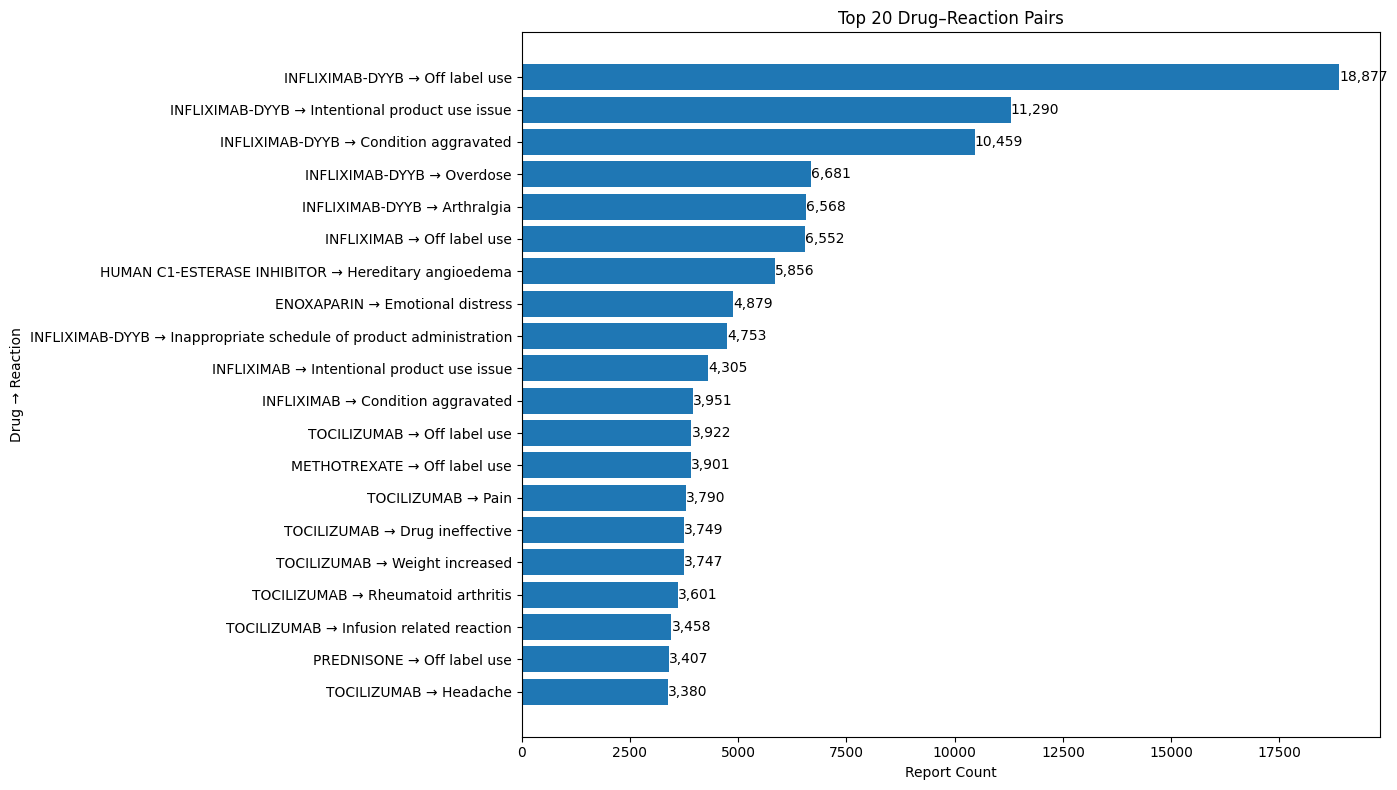

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.barh(
    top20_drug_reac_df['pair'],
    top20_drug_reac_df['count']
)

plt.title('Top 20 Drug–Reaction Pairs')
plt.xlabel('Report Count')
plt.ylabel('Drug → Reaction')

for i, v in enumerate(top20_drug_reac_df['count']):
    plt.text(v + 2, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

# **4. Conclusion**

This project analyzed adverse event reports from the FDA Adverse Event Reporting System (FAERS) to identify patterns across patient demographics, reported reactions, clinical outcomes, and drug-related risks.

Key findings from the analysis include:

- Adverse event reports were concentrated among middle-aged and elderly patients, with older age groups exhibiting a higher proportion of severe outcomes.
- Female patients accounted for a larger share of reported adverse events compared to male patients.
- Reporting activity was heavily concentrated in a small number of countries, led by the United States.
- Several adverse reactions, including nausea, fatigue, headache, and dizziness, appeared frequently across severe outcome categories such as hospitalization and death.
- Reaction patterns varied across age groups, indicating potential differences in drug response between younger and elderly populations.
- A relatively small group of drugs accounted for a significant proportion of reported adverse events and severe outcomes.
- Analysis of drug–reaction pairs highlighted recurring associations that may warrant further pharmacovigilance monitoring.

Overall, the project demonstrates how large-scale healthcare safety data can be transformed into actionable insights using Python-based exploratory data analysis techniques. While FAERS data cannot establish causal relationships, it serves as a valuable resource for identifying reporting trends, safety signals, and areas requiring further clinical investigation.

# **5. Limitations**

- FAERS is a voluntary reporting system and may be subject to under-reporting.
- Reports may contain missing, incomplete, or inconsistent information.
- The presence of an adverse event report does not establish causality between a drug and a reaction.
- Reporting frequency should not be interpreted as actual incidence rates in the population.
- Duplicate reports and reporting biases may influence observed patterns.

# **6. Future Work**

- Rebuild the analysis using PySpark for large-scale distributed processing.
- Implement equivalent transformations and aggregations in Databricks.
- Develop interactive dashboards using Power BI.
- Perform advanced signal detection and risk analysis on drug–reaction associations.
- Extend the analysis to multiple FAERS reporting periods for trend analysis over time.